<a href="https://colab.research.google.com/github/Dawood-Ali123/Pytorch_learning/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("preronakar/fminst")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fminst' dataset.
Path to dataset files: /kaggle/input/fminst


In [22]:
import os
filename=os.listdir(path)[0]

In [23]:
torch.manual_seed(42)

In [24]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [25]:
df=pd.read_csv(path+"/"+filename)
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [26]:
df.shape

(6000, 785)

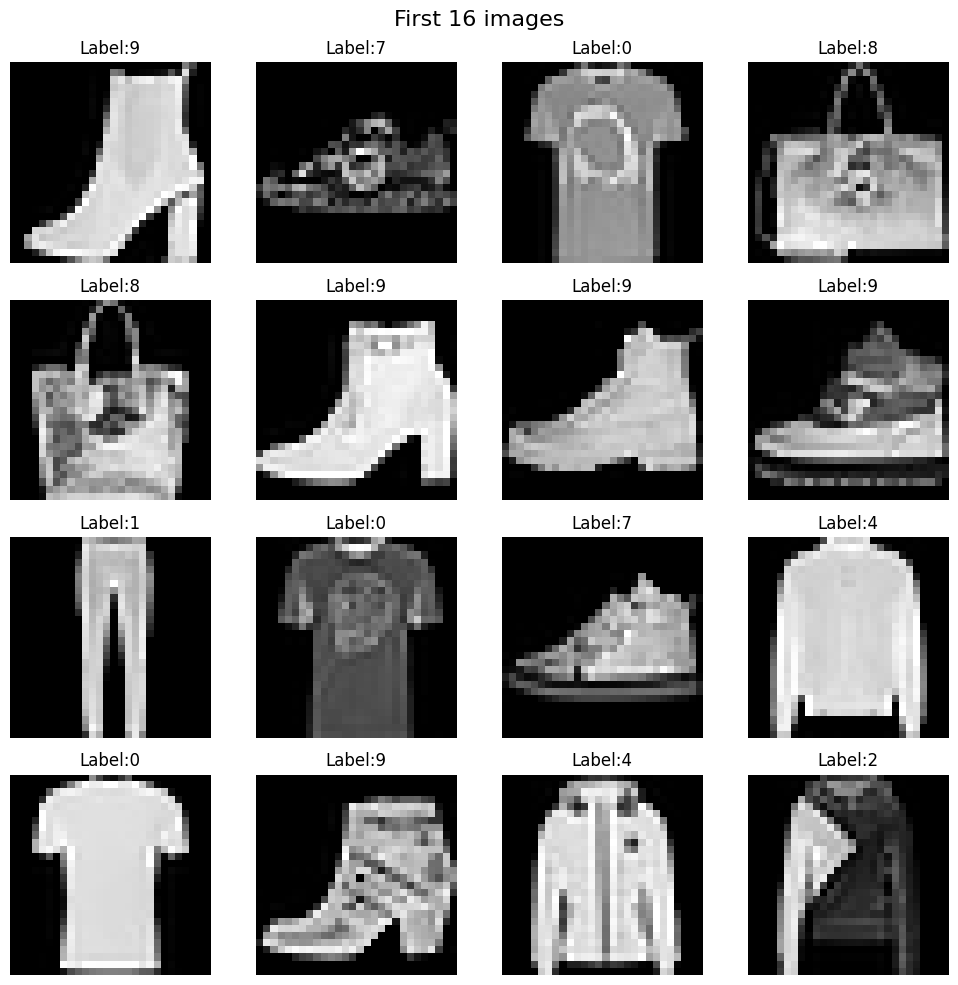

In [27]:
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First 16 images",fontsize=16)
for i,ax in enumerate(axes.flat):
    ax.imshow(df.iloc[i,1:].values.reshape(28,28),cmap="gray")
    ax.axis("off")
    ax.set_title(f"Label:{df.iloc[i,0]}")
plt.tight_layout()
plt.show()

In [28]:
X=df.iloc[:,1:].values
Y=df.iloc[:,0]

In [29]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
X_train=X_train/255.0
Y_train=Y_train/255.0
X_test=X_test/255.0
Y_test=Y_test/255.0

In [30]:
X_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]])

In [31]:
Y_test=Y_test.to_numpy()

In [32]:
class CustomDataset(Dataset):
    def __init__(self,features,labels):
      #convert to the pytorch tensors
      self.features=torch.tensor(features,dtype=torch.float32).reshape(-1,1,28,28)
      self.labels=torch.tensor(labels,dtype=torch.long)

    def __len__(self):
      return len(self.features)

    def __getitem__(self,idx):
      return self.features[idx],self.labels[idx]


In [33]:
train_dataset=CustomDataset(X_train,Y_train)
test_dataset=CustomDataset(X_test,Y_test)

In [34]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)

In [56]:
class MYNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()


    self.features=nn.Sequential(
        nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2,stride=2),

        nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*7*7,128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(64,10),

    )

  def forward(self,x):
    x=self.features(x)
    x=self.classifier(x)
    return x

In [58]:
learning_rate=0.01;
epoches=100

In [57]:
from torch.optim import optimizer
model=MYNN(X_train.shape[1]).to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=learning_rate)

In [59]:
#trainong loop
for epoch in range(epoches):
  total_epoch_loss=0
  for batch_Features,batch_lables in train_loader:
    batch_Features=batch_Features.to(device)
    batch_lables=batch_lables.to(device)
    output=model(batch_Features)
    loss=criterion(output,batch_lables)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_epoch_loss+=loss.item()
    avg_loss=total_epoch_loss/len(train_loader)
    print(f'Epoch:{epoch+1}/{epoches},loss:{avg_loss:.4f}')

Streaming output truncated to the last 5000 lines.
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000
Epoch:67/100,loss:0.0000

In [62]:
model.eval()

MYNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.5, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [63]:
total=0
correct=0
with torch.no_grad():
  for batch_Features,batch_lables in test_loader:
    batch_Features=batch_Features.to(device)
    batch_lables=batch_lables.to(device)
    outputs=model(batch_Features)
    _,predicted=torch.max(outputs.data,1)
    total+=batch_lables.size(0)
    correct+=(predicted==batch_lables).sum().item()
  print(correct/total)

1.0


In [64]:
total=0
correct=0
with torch.no_grad():
  for batch_Features,batch_lables in test_loader:
    batch_Features=batch_Features.to(device)
    batch_lables=batch_lables.to(device)
    outputs=model(batch_Features)
    _,predicted=torch.max(outputs.data,1)
    total+=batch_lables.size(0)
    correct+=(predicted==batch_lables).sum().item()
  print(correct/total)

1.0
